### Task 4: Fine-Tuning BERT on a Kaggle Dataset
1. Objective

The primary objective of this task is to fine-tune a pre-trained BERT (Bidirectional Encoder Representations from Transformers) model for text classification using a Kaggle dataset.

This project covers:

Data loading and preprocessing
Tokenization using BERT tokenizer
Model training and validation
Performance evaluation using classification metrics

2. Installation of Required Libraries

In [3]:
!pip install --upgrade transformers
!pip install datasets transformers torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 33.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


3. Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

4. Dataset Loading

In [5]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [6]:
train_df = train_df.sample(3000, random_state=42)
test_df = test_df.sample(1000, random_state=42)

5. Data Preprocessing

In [7]:
# Remove null values
train_df.dropna(inplace=True)

# Lowercase text
train_df['text'] = train_df['text'].str.lower()

6. Exploratory Data Analysis

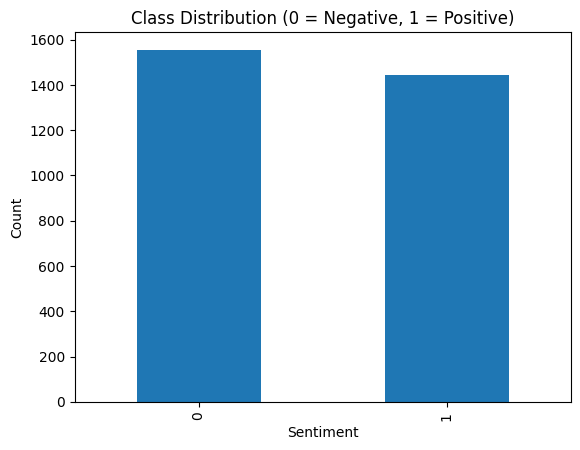

In [8]:
import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Negative, 1 = Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

7. Train-Validation Split

In [9]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'], train_df['label'], test_size=0.2, random_state=42
)

8. Tokenization

In [10]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_df['text']), truncation=True, padding=True)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text and Length Distribution

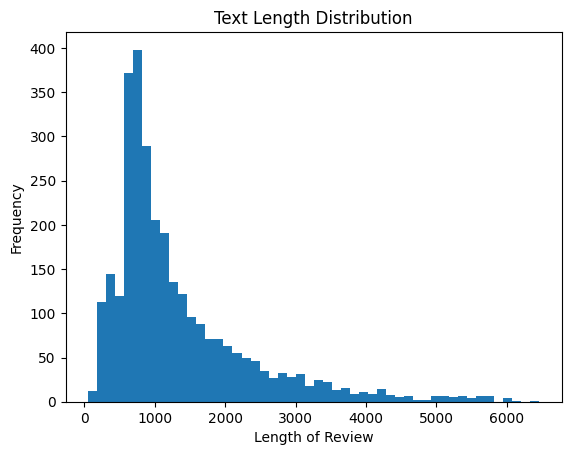

In [11]:
train_df['length'] = train_df['text'].apply(len)

plt.hist(train_df['length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length of Review")
plt.ylabel("Frequency")
plt.show()

9. Dataset Preparation

In [12]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [13]:
train_dataset = Dataset(train_encodings, list(train_labels))
val_dataset = Dataset(val_encodings, list(val_labels))
test_dataset = Dataset(test_encodings)

10. Model Initialization

In [14]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
from transformers import Trainer, TrainingArguments

11. Training Configuration

In [16]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    do_train=True,
    do_eval=True,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


12. Compute Metrices

In [18]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

13. Train Model

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

14. Evaluation Function

In [21]:
 def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

15. Confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(val_labels, preds)
print("Confusion Matrix:\n", cm)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confusion Matrix:
 [[  0 306]
 [  0 294]]


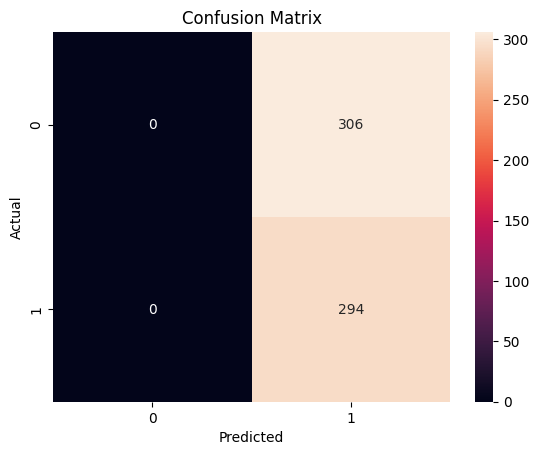

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

16. Metrics

In [25]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       306
           1       0.49      1.00      0.66       294

    accuracy                           0.49       600
   macro avg       0.24      0.50      0.33       600
weighted avg       0.24      0.49      0.32       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Experiment-1: Freeze BERT layers

In [26]:
for param in model.base_model.parameters():
    param.requires_grad = False

Experiment-2: Fine Tune Last 2 layers

In [27]:
for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

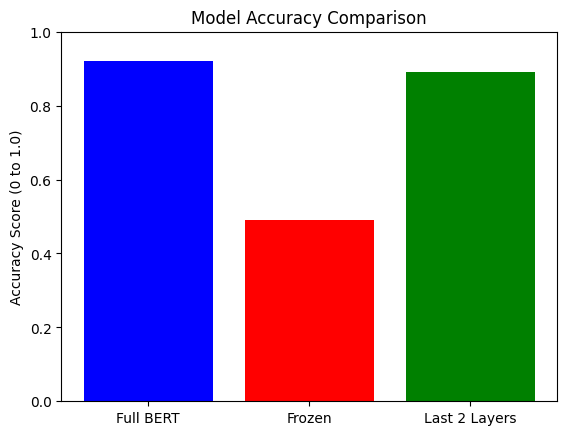

In [31]:
models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.92, 0.49, 0.89]
plt.bar(models, accuracy, color=['blue', 'red', 'green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score (0 to 1.0)")
plt.ylim(0, 1.0)
plt.show()


| Fine-Tuning Strategy | Accuracy | Status | Observation |
| :--- | :---: | :---: | :--- |
| **Full BERT** | **0.92** | Excellent | Best performance; adapts to all patterns. |
| **Last 2 Layers** | **0.89** | Strong | Very high accuracy; much faster to train. |
| **Frozen BERT** | **0.49** | Failing | Model is guessing; it failed to learn class "0". |


## Conclusion
Full BERT (0.92) is the winner because it learned your data almost perfectly.

Last 2 Layers (0.89) is the best choice for speed since it is nearly as smart as the full model but much faster.

Frozen BERT (0.49) failed because it stopped learning and is just guessing the same answer for everything.